In [15]:
import subprocess
import pandas as pd
import os
from pathlib import Path

In [4]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
CHROM_BASE_PATH = "/home/jupyter/gcs"
PRS_VARIANTS_FILE = "/home/jupyter/PGS004946.txt"
PATIENT_ID_FILE = "/home/jupyter/dcm_person_ids.csv" 
PATIENT_ID_COLUMN = "PERSON_ID" 

# Output directory
OUTPUT_DIR = "/home/jupyter/prs_output_dcm"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Total DCM variants: 1098677

First few variants:
        rsID  chr_name  chr_position effect_allele other_allele  effect_weight
0  rs6657381         1       5039093             T            C       0.000201
1  rs1841241         1       5039380             G            A      -0.000005
2  rs2334268         1       5042266             T            C      -0.000030
3  rs1563791         1       5043734             A            C       0.000079
4  rs6679312         1       5047038             G            A       0.000156

50% of total effect captured by top 137843 variants (12.5% of all variants)

75% of total effect captured by top 345741 variants (31.5% of all variants)

90% of total effect captured by top 590765 variants (53.8% of all variants)

95% of total effect captured by top 731453 variants (66.6% of all variants)

99% of total effect captured by top 931490 variants (84.8% of all variants)


/var/tmp/ipykernel_5253/1153072046.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


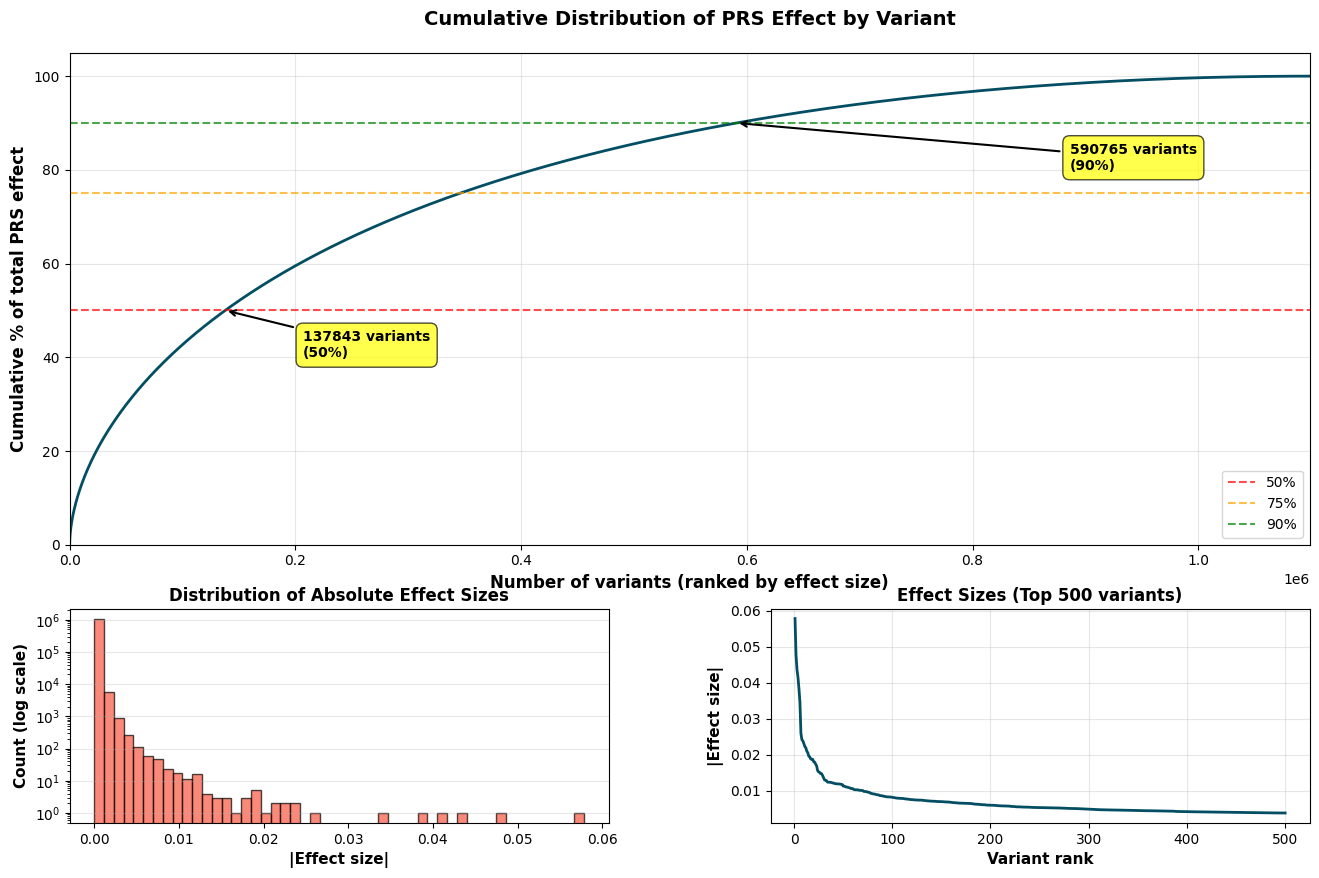

                 Metric     Value
         Total variants 1,098,677
Variants for 50% effect   137,843
Variants for 75% effect   345,741
Variants for 90% effect   590,765
Variants for 95% effect   731,453
   Mean absolute effect  0.000131
 Median absolute effect  0.000070
    Max absolute effect  0.057870


In [27]:
dcm_pgs = pd.read_csv(PRS_VARIANTS_FILE, sep='\t')

print(f"\nTotal DCM variants: {len(dcm_pgs)}")
print("\nFirst few variants:")
print(dcm_pgs.head())

# Sort by abs effect size
dcm_pgs['abs_effect'] = dcm_pgs['effect_weight'].abs()
dcm_pgs_sorted = dcm_pgs.sort_values('abs_effect', ascending=False).reset_index(drop=True)

# Calculate cumulative contribution
dcm_pgs_sorted['cumulative_abs_effect'] = dcm_pgs_sorted['abs_effect'].cumsum()
total_abs_effect = dcm_pgs_sorted['abs_effect'].sum()
dcm_pgs_sorted['cumulative_percent'] = (dcm_pgs_sorted['cumulative_abs_effect'] / total_abs_effect) * 100

# Find how many variants contribute to different percentages
for pct in [50, 75, 90, 95, 99]:
    n_variants = (dcm_pgs_sorted['cumulative_percent'] <= pct).sum()
    print(f"\n{pct}% of total effect captured by top {n_variants} variants ({n_variants/len(dcm_pgs)*100:.1f}% of all variants)")

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Cumulative contribution curve 
ax1 = fig.add_subplot(gs[0:2, :])
ax1.plot(range(1, len(dcm_pgs_sorted)+1), dcm_pgs_sorted['cumulative_percent'].values, 
         linewidth=2, color='#034E63')
ax1.axhline(50, color='red', linestyle='--', alpha=0.7, label='50%')
ax1.axhline(75, color='orange', linestyle='--', alpha=0.7, label='75%')
ax1.axhline(90, color='green', linestyle='--', alpha=0.7, label='90%')
ax1.set_xlabel('Number of variants (ranked by effect size)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative % of total PRS effect', fontsize=12, fontweight='bold')
ax1.set_title('Cumulative Distribution of PRS Effect by Variant', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, len(dcm_pgs_sorted))
ax1.set_ylim(0, 105)

#Annotations for key percentiles
for pct in [50, 90]:
    n_variants = (dcm_pgs_sorted['cumulative_percent'] <= pct).sum()
    ax1.annotate(f'{n_variants} variants\n({pct}%)', 
                xy=(n_variants, pct),
                xytext=(n_variants * 1.5, pct - 10),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

#Distribution of absolute effect sizes (log scale)
ax2 = fig.add_subplot(gs[2, 0])
ax2.hist(dcm_pgs['abs_effect'], bins=50, edgecolor='black', color='#F95741', alpha=0.7)
ax2.set_xlabel('|Effect size|', fontsize=11, fontweight='bold')
ax2.set_ylabel('Count (log scale)', fontsize=11, fontweight='bold')
ax2.set_title('Distribution of Absolute Effect Sizes', fontsize=12, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, axis='y')

# Effect sizes by rank 
ax3 = fig.add_subplot(gs[2, 1])
top_n_show = min(500, len(dcm_pgs_sorted))
ax3.plot(range(1, top_n_show+1), dcm_pgs_sorted['abs_effect'].head(top_n_show).values,
         linewidth=2, color='#034E63')
ax3.set_xlabel('Variant rank', fontsize=11, fontweight='bold')
ax3.set_ylabel('|Effect size|', fontsize=11, fontweight='bold')
ax3.set_title(f'Effect Sizes (Top {top_n_show} variants)', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
figure_dcm_prs_cumulative = plt.gcf()
plt.show()


summary_stats = pd.DataFrame({
    'Metric': [
        'Total variants',
        'Variants for 50% effect',
        'Variants for 75% effect',
        'Variants for 90% effect',
        'Variants for 95% effect',
        'Mean absolute effect',
        'Median absolute effect',
        'Max absolute effect'
    ],
    'Value': [
        f"{len(dcm_pgs):,}",
        f"{(dcm_pgs_sorted['cumulative_percent'] <= 50).sum():,}",
        f"{(dcm_pgs_sorted['cumulative_percent'] <= 75).sum():,}",
        f"{(dcm_pgs_sorted['cumulative_percent'] <= 90).sum():,}",
        f"{(dcm_pgs_sorted['cumulative_percent'] <= 95).sum():,}",
        f"{dcm_pgs['abs_effect'].mean():.6f}",
        f"{dcm_pgs['abs_effect'].median():.6f}",
        f"{dcm_pgs['abs_effect'].max():.6f}"
    ]
})

print(summary_stats.to_string(index=False))

# Save
output_file = f"{OUTPUT_DIR}/dcm_pgs_ranked_cumulative.txt"
dcm_pgs_sorted.to_csv(output_file, sep='\t', index=False)


Variants needed for 50% cumulative effect: 137,843
This is 12.55% of all variants

Subset size: 137,843 variants
Min |effect| in subset: 0.000252
Max |effect| in subset: 0.057870
Mean |effect| in subset: 0.000522
COMPARISON: SUBSET vs FULL SET
            Dataset N variants Sum |effect|
           Full set  1,098,677     144.0108
Subset (50% effect)    137,843      72.0053
          Reduction      87.5%        50.0%
Saved variant ID list to: /home/jupyter/prs_output_dcm/dcm_pgs_top50pct_variant_ids.txt


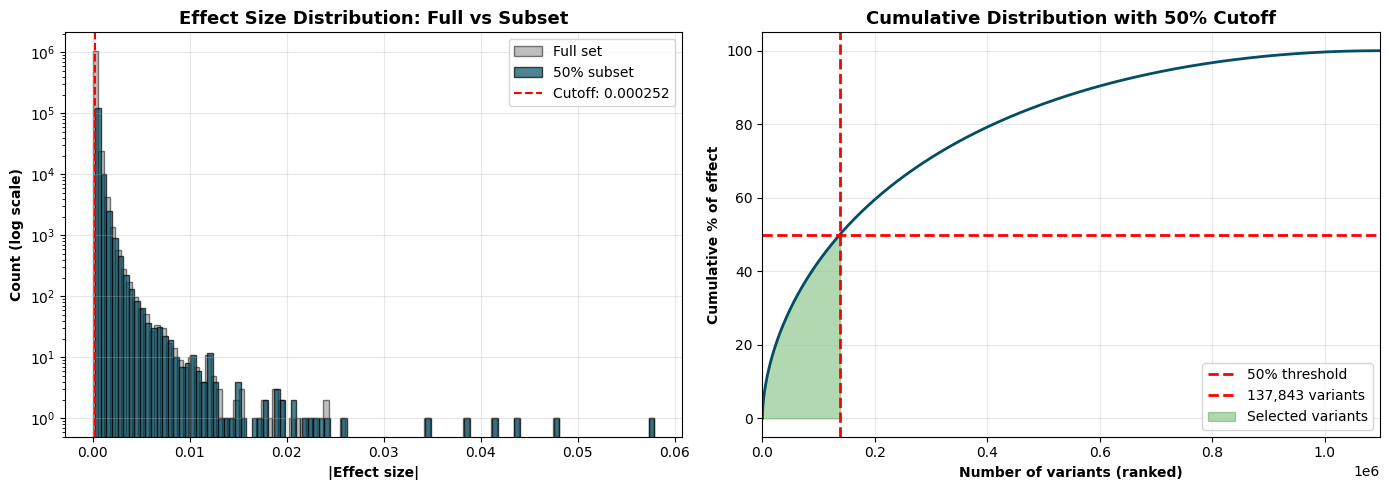

In [28]:
# Determine cutoff for 50% cumulative effect
cumulative_threshold = 50  
n_variants_50pct = (dcm_pgs_sorted['cumulative_percent'] <= cumulative_threshold).sum()

print(f"\nVariants needed for {cumulative_threshold}% cumulative effect: {n_variants_50pct:,}")
print(f"This is {n_variants_50pct/len(dcm_pgs)*100:.2f}% of all variants")

# Subset to these top variants
dcm_pgs_subset = dcm_pgs_sorted.head(n_variants_50pct).copy()

print(f"\nSubset size: {len(dcm_pgs_subset):,} variants")
print(f"Min |effect| in subset: {dcm_pgs_subset['abs_effect'].min():.6f}")
print(f"Max |effect| in subset: {dcm_pgs_subset['abs_effect'].max():.6f}")
print(f"Mean |effect| in subset: {dcm_pgs_subset['abs_effect'].mean():.6f}")

# Compare to full set
print("COMPARISON: SUBSET vs FULL SET")

comparison = pd.DataFrame({
    'Dataset': ['Full set', 'Subset (50% effect)', 'Reduction'],
    'N variants': [
        f"{len(dcm_pgs):,}",
        f"{len(dcm_pgs_subset):,}",
        f"{(1 - n_variants_50pct/len(dcm_pgs))*100:.1f}%"
    ],
    'Sum |effect|': [
        f"{dcm_pgs['abs_effect'].sum():.4f}",
        f"{dcm_pgs_subset['abs_effect'].sum():.4f}",
        f"{dcm_pgs_subset['abs_effect'].sum() / dcm_pgs['abs_effect'].sum() * 100:.1f}%"
    ]
})
print(comparison.to_string(index=False))

# Save
output_file = f"{OUTPUT_DIR}/dcm_pgs_top50pct_n{n_variants_50pct}.txt"
dcm_pgs_subset.to_csv(output_file, sep='\t', index=False)

# save just variant IDs
variant_list_file = f"{OUTPUT_DIR}/dcm_pgs_top50pct_variant_ids.txt"
dcm_pgs_subset[['rsID']].to_csv(variant_list_file, sep='\t', index=False, header=False)
print(f"Saved variant ID list to: {variant_list_file}")

# Visualization comparing distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effect size distribution comparison
axes[0].hist(dcm_pgs['abs_effect'], bins=100, alpha=0.5, label='Full set', color='gray', edgecolor='black')
axes[0].hist(dcm_pgs_subset['abs_effect'], bins=100, alpha=0.7, label='50% subset', color='#034E63', edgecolor='black')
axes[0].axvline(dcm_pgs_subset['abs_effect'].min(), color='red', linestyle='--', 
                label=f'Cutoff: {dcm_pgs_subset["abs_effect"].min():.6f}')
axes[0].set_xlabel('|Effect size|', fontweight='bold')
axes[0].set_ylabel('Count (log scale)', fontweight='bold')
axes[0].set_title('Effect Size Distribution: Full vs Subset', fontweight='bold', fontsize=13)
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Cumulative curve with cutoff
axes[1].plot(range(1, len(dcm_pgs_sorted)+1), dcm_pgs_sorted['cumulative_percent'], 
             linewidth=2, color='#034E63')
axes[1].axhline(50, color='red', linestyle='--', linewidth=2, label='50% threshold')
axes[1].axvline(n_variants_50pct, color='red', linestyle='--', linewidth=2, 
                label=f'{n_variants_50pct:,} variants')
axes[1].fill_between(range(1, n_variants_50pct+1), 
                      0, dcm_pgs_sorted['cumulative_percent'].head(n_variants_50pct),
                      alpha=0.3, color='green', label='Selected variants')
axes[1].set_xlabel('Number of variants (ranked)', fontweight='bold')
axes[1].set_ylabel('Cumulative % of effect', fontweight='bold')
axes[1].set_title('Cumulative Distribution with 50% Cutoff', fontweight='bold', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, len(dcm_pgs_sorted))

plt.tight_layout()
figure_dcm_prs_subset = plt.gcf()
plt.show()

In [29]:
REFERENCE_PSAM = f"{CHROM_BASE_PATH}/chrom-1/postproc-pgen/dragen.psam"  # Using chr1 as reference

In [30]:
psam_df = pd.read_csv(REFERENCE_PSAM, sep='\t')
if '#FID' in psam_df.columns:
    psam_df.rename(columns={'#FID': 'FID'}, inplace=True)

print(f"Loaded {len(psam_df):,} total samples")
print(f"   Columns: {list(psam_df.columns)}")
print(psam_df[['FID', 'IID']].head(20))

Loaded 250,115 total samples
   Columns: ['FID', 'IID', 'SEX']
              FID            IID
0   HG001_PrecFDA  HG001_PrecFDA
1    HG002_DeCODE   HG002_DeCODE
2   HG002_PrecFDA  HG002_PrecFDA
3    HG003_DeCODE   HG003_DeCODE
4   HG003_PrecFDA  HG003_PrecFDA
5    HG004_DeCODE   HG004_DeCODE
6   HG004_PrecFDA  HG004_PrecFDA
7   HG005_PrecFDA  HG005_PrecFDA
8   HG006_PrecFDA  HG006_PrecFDA
9   HG007_PrecFDA  HG007_PrecFDA
10     R200000348     R200000348
11     R200000649     R200000649
12     R200001537     R200001537
13     R200002217     R200002217
14     R200003540     R200003540
15     R200004194     R200004194
16     R200004714     R200004714
17     R200005147     R200005147
18     R200005372     R200005372
19     R200005757     R200005757


In [31]:
if PATIENT_ID_COLUMN:
    patient_df = pd.read_csv(PATIENT_ID_FILE)
    patient_ids = patient_df[PATIENT_ID_COLUMN].astype(str).tolist()

print(f"Loaded {len(patient_ids)} HCM patient IDs")

# Match patient IDs with FID/IID from .psam file
patient_ids_set = set(str(pid) for pid in patient_ids)

#psam IDs to strings for matching
psam_df['FID_str'] = psam_df['FID'].astype(str)
psam_df['IID_str'] = psam_df['IID'].astype(str)

# Filter to only patients in DCM cohort
matched_samples = psam_df[psam_df['IID_str'].isin(patient_ids_set)].copy()

print(f"\n Matched {len(matched_samples)} patients")

if len(matched_samples) < len(patient_ids):
    missing_count = len(patient_ids) - len(matched_samples)
    print(f"Warning: {missing_count} patient IDs not found in .psam file")
    
    matched_ids = set(matched_samples['IID_str'].tolist()) | set(matched_samples['FID_str'].tolist())
    missing_ids = [pid for pid in patient_ids if str(pid) not in matched_ids]
    if missing_ids:
        print(f"   Missing IDs example: {missing_ids[:5]}")

Loaded 5413 HCM patient IDs

 Matched 1243 patients
   Missing IDs example: ['R200022632', 'R200036636', 'R200044004', 'R200113008', 'R200114568']


In [9]:
dcm_keep_file = f"{OUTPUT_DIR}/dcm_cohort.keep"
matched_samples[['FID', 'IID']].to_csv(dcm_keep_file, sep='\t', header=False, index=False)
print(f"   DCM cohort keep file: {dcm_keep_file}")
print(f"   Contains {len(matched_samples)} patients")

print(f"\n Total samples in dataset: {len(psam_df)}")
print(f"   DCM cohort: {len(matched_samples)}")
print(f"   General population (non-DCM): {len(psam_df) - len(matched_samples)}")

NameError: name 'matched_samples' is not defined

In [1]:
PLINK2_PATH = "/opt/conda/envs/mf_cm/bin/plink2"

In [10]:
import pandas as pd
import subprocess
import os

OUTPUT_DIR = "/home/jupyter/prs_output_dcm"
prs_final = pd.read_csv('/home/jupyter/prs_output_dcm/dcm_pgs_chr_pos_ref_alt.txt', sep='\t')

# Group by chromosome
prs_by_chrom = {}
for chrom in prs_final['chr'].unique():
    chrom_data = prs_final[prs_final['chr'] == chrom]
    prs_by_chrom[chrom] = chrom_data[['variant_id', 'alt', 'effect_weight']].to_dict('records')

print(f"Total variants: {len(prs_final):,}")
print(f"Chromosomes: {sorted(prs_by_chrom.keys())}")

def extract_chromosome(chrom):
    
    variants = prs_by_chrom[chrom]
    chrom_num = chrom.replace('chr', '')
    print(f"Processing {chrom}: {len(variants)} variants")
    # Write variant list
    variant_file = f"{OUTPUT_DIR}/dcm_prs_{chrom}_variants.txt"
    variant_ids = [v['variant_id'] for v in variants]
    with open(variant_file, 'w') as f:
        f.write('\n'.join(variant_ids))
    print(f" Variant list saved: {len(variant_ids)} variants")
    
    chrom_dir = f"/home/jupyter/gcs/chrom-{chrom_num}/postproc-pgen"
    pfile_prefix = f"{chrom_dir}/dragen"
    output_prefix = f"{OUTPUT_DIR}/dcm_prs_{chrom}"
    
    # Check if already done
    output_file = f"{output_prefix}.raw"
    if os.path.exists(output_file):
        print(f" Output already exists: {output_file}")
        response = input("Overwrite? (y/n): ")
        if response.lower() != 'y':
            print("Skipping...")
            return output_file
    

    cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--extract", variant_file,
        "--export", "A",
        "--out", output_prefix
    ]
    
    print(f"Running PLINK2...")
    
    try:
        result = subprocess.run(cmd, capture_output=True, text=True, timeout=10000)
        
        if result.returncode != 0:
            print(f" PLINK2 Error (code {result.returncode}):")
            print(result.stderr[:1000])
            return None
        
        # Check output
        if os.path.exists(output_file):
            with open(output_file, 'r') as f:
                header = f.readline()
                all_cols = header.strip().split()
                standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
                variant_cols = [col for col in all_cols if col not in standard_cols]
                n_variants = len(variant_cols)
            
            extraction_rate = (n_variants / len(variants)) * 100
            print(f" Extracted {n_variants}/{len(variants)} variants ({extraction_rate:.1f}%)")
            print(f" Saved: {output_file}")
            return output_file
        else:
            print(f" No output file generated")
            return None
            
    except subprocess.TimeoutExpired:
        print(f" Timeout")
        return None
    except Exception as e:
        print(f" Exception: {e}")

Total variants: 136,593
Chromosomes: ['chr1', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14', 'chr15', 'chr16', 'chr17', 'chr18', 'chr19', 'chr2', 'chr20', 'chr21', 'chr22', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chr8', 'chr9']


In [39]:
extract_chromosome('chr3')

Processing chr3: 10054 variants
 Variant list saved: 10054 variants
Running PLINK2...
 Extracted 10054/10054 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr3.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr3.raw'

In [42]:
extract_chromosome('chr4')

Processing chr4: 8065 variants
 Variant list saved: 8065 variants
 Output already exists: /home/jupyter/prs_output_dcm/dcm_prs_chr4.raw


Overwrite? (y/n):  y


Running PLINK2...
 Extracted 8065/8065 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr4.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr4.raw'

In [44]:
extract_chromosome('chr5')

Processing chr5: 8779 variants
 Variant list saved: 8779 variants
 Output already exists: /home/jupyter/prs_output_dcm/dcm_prs_chr5.raw


Overwrite? (y/n):  y


Running PLINK2...
 Extracted 8779/8779 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr5.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr5.raw'

In [45]:
extract_chromosome('chr6')

Processing chr6: 9330 variants
 Variant list saved: 9330 variants
Running PLINK2...
 Extracted 9330/9330 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr6.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr6.raw'

In [46]:
extract_chromosome('chr7')

Processing chr7: 7482 variants
 Variant list saved: 7482 variants
Running PLINK2...
 Extracted 7482/7482 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr7.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr7.raw'

In [12]:
extract_chromosome('chr8')

Processing chr8: 7078 variants
 Variant list saved: 7078 variants
 Output already exists: /home/jupyter/prs_output_dcm/dcm_prs_chr8.raw


Overwrite? (y/n):  y


Running PLINK2...
 Extracted 7078/7078 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr8.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr8.raw'

In [13]:
extract_chromosome('chr9')

Processing chr9: 5937 variants
 Variant list saved: 5937 variants
Running PLINK2...
 Extracted 5937/5937 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr9.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr9.raw'

In [14]:
extract_chromosome('chr10')

Processing chr10: 7169 variants
 Variant list saved: 7169 variants
Running PLINK2...
 Extracted 7169/7169 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr10.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr10.raw'

In [16]:
extract_chromosome('chr11')

Processing chr11: 6685 variants
 Variant list saved: 6685 variants
 Output already exists: /home/jupyter/prs_output_dcm/dcm_prs_chr11.raw


Overwrite? (y/n):  y


Running PLINK2...
 Extracted 6685/6685 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr11.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr11.raw'

In [17]:
extract_chromosome('chr12')

Processing chr12: 6981 variants
 Variant list saved: 6981 variants
Running PLINK2...
 Extracted 6981/6981 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr12.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr12.raw'

In [18]:
extract_chromosome('chr13')

Processing chr13: 4968 variants
 Variant list saved: 4968 variants
Running PLINK2...
 Extracted 4968/4968 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr13.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr13.raw'

In [19]:
extract_chromosome('chr14')

Processing chr14: 4415 variants
 Variant list saved: 4415 variants
Running PLINK2...
 Extracted 4415/4415 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr14.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr14.raw'

In [20]:
extract_chromosome('chr15')

Processing chr15: 4480 variants
 Variant list saved: 4480 variants
Running PLINK2...
 Extracted 4480/4480 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr15.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr15.raw'

In [21]:
extract_chromosome('chr16')

Processing chr16: 4332 variants
 Variant list saved: 4332 variants
Running PLINK2...
 Extracted 4332/4332 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr16.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr16.raw'

In [22]:
extract_chromosome('chr17')

Processing chr17: 3671 variants
 Variant list saved: 3671 variants
Running PLINK2...
 Extracted 3671/3671 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr17.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr17.raw'

In [23]:
extract_chromosome('chr18')

Processing chr18: 3913 variants
 Variant list saved: 3913 variants
Running PLINK2...
 Extracted 3913/3913 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr18.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr18.raw'

In [24]:
extract_chromosome('chr19')

Processing chr19: 2420 variants
 Variant list saved: 2420 variants
Running PLINK2...
 Extracted 2420/2420 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr19.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr19.raw'

In [25]:
extract_chromosome('chr20')

Processing chr20: 3399 variants
 Variant list saved: 3399 variants
Running PLINK2...
 Extracted 3399/3399 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr20.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr20.raw'

In [26]:
extract_chromosome('chr21')

Processing chr21: 2095 variants
 Variant list saved: 2095 variants
Running PLINK2...
 Extracted 2095/2095 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr21.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr21.raw'

In [27]:
extract_chromosome('chr22')

Processing chr22: 1855 variants
 Variant list saved: 1855 variants
Running PLINK2...
 Extracted 1855/1855 variants (100.0%)
 Saved: /home/jupyter/prs_output_dcm/dcm_prs_chr22.raw


'/home/jupyter/prs_output_dcm/dcm_prs_chr22.raw'

In [16]:
import pandas as pd
import os
import glob
import numpy as np

# Configuration
OUTPUT_DIR = "/home/jupyter/prs_output_dcm"

# Load weights
print("Loading weights...")
prs_final = pd.read_csv('/home/jupyter/prs_output_dcm/dcm_pgs_chr_pos_ref_alt.txt', sep='\t')
weight_dict = {row['variant_id']: row['effect_weight'] for idx, row in prs_final.iterrows()}
print(f"Total variants with weights: {len(weight_dict)}")

prs_file = f"{OUTPUT_DIR}/dcm_prs_cumulative.tsv"
if os.path.exists(prs_file):
    all_prs_scores = pd.read_csv(prs_file, sep='\t')
    print(f" Loaded existing PRS file: {len(all_prs_scores)} samples")
else:
    # Initialize from first chromosome file
    first_file = f"{OUTPUT_DIR}/dcm_prs_chr1.raw"
    df = pd.read_csv(first_file, sep='\t', usecols=['FID', 'IID'])
    all_prs_scores = df.copy()
    all_prs_scores['PRS'] = 0.0
    all_prs_scores.to_csv(prs_file, sep='\t', index=False)
    print(f" Initialized new PRS file: {len(all_prs_scores)} samples")

def process_chromosome(chrom_num):
    """Process a single chromosome and add to cumulative PRS"""
    
    chrom = f"chr{chrom_num}"
    raw_file = f"{OUTPUT_DIR}/dcm_prs_{chrom}.raw"
    
    if not os.path.exists(raw_file):
        print(f"File not found: {raw_file}")
        return
    
    print(f"Processing {chrom}")
    
    # Read header
    with open(raw_file, 'r') as f:
        header = f.readline().strip().split('\t')
    
    standard_cols = ['FID', 'IID', 'PAT', 'MAT', 'SEX', 'PHENOTYPE']
    variant_cols = [col for col in header if col not in standard_cols]
    
    # Map variants to weights
    variant_weights = {}
    for var_col in variant_cols:
        var_id = var_col.rsplit('_', 1)[0] if '_' in var_col else var_col
        if var_id in weight_dict:
            variant_weights[var_col] = weight_dict[var_id]
    
    print(f"Variants: {len(variant_weights)}/{len(variant_cols)} with weights")
    
    # Load cumulative PRS
    global all_prs_scores
    prs_file = f"{OUTPUT_DIR}/dcm_prs_cumulative.tsv"
    all_prs_scores = pd.read_csv(prs_file, sep='\t')
    
    # Create a sample lookup dictionary for faster matching (OPTIMIZATION)
    all_prs_scores['sample_key'] = all_prs_scores['FID'].astype(str) + '_' + all_prs_scores['IID'].astype(str)
    sample_lookup = {key: idx for idx, key in enumerate(all_prs_scores['sample_key'])}
    
    # Process in chunks (500 samples at a time)
    chunk_iter = pd.read_csv(raw_file, sep='\t', chunksize=5000)
    
    chunk_count = 0
    for chunk in chunk_iter:
        chunk_count += 1
        
        if variant_weights:
            weight_cols = list(variant_weights.keys())
            weights_array = np.array([variant_weights[col] for col in weight_cols])
            dosage_matrix = chunk[weight_cols].fillna(0).values
            prs_contribution = dosage_matrix @ weights_array  
            
            # Match samples using lookup (MUCH FASTER)
            chunk['sample_key'] = chunk['FID'].astype(str) + '_' + chunk['IID'].astype(str)
            for idx, sample_key in enumerate(chunk['sample_key']):
                if sample_key in sample_lookup:
                    sample_idx = sample_lookup[sample_key]
                    all_prs_scores.loc[sample_idx, 'PRS'] += prs_contribution[idx]
        
        del chunk
        if chunk_count % 5 == 0:
            print(f"  Processed ~{chunk_count * 5000} samples...", end='\r')
    
    print(f"   Processed all samples                    ")
    
    # Remove temporary column
    all_prs_scores.drop('sample_key', axis=1, inplace=True)
    
    # Save cumulative PRS
    all_prs_scores.to_csv(prs_file, sep='\t', index=False)
    print(f"Saved cumulative PRS: {prs_file}")
    
    # Show current stats
    print(f"\nCurrent PRS stats:")
    print(all_prs_scores['PRS'].describe())

print("\nSetup complete. Run process_chromosome(N) for each chromosome.")
print("Example: process_chromosome(17)")

Loading weights...
Total variants with weights: 136593
 Loaded existing PRS file: 250115 samples

Setup complete. Run process_chromosome(N) for each chromosome.
Example: process_chromosome(17)


In [3]:
 process_chromosome(1)

Processing chr1
Variants: 11683/11683 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          0.454845
std           0.101909
min           0.003089
25%           0.387070
50%           0.456826
75%           0.524792
max           0.893854
Name: PRS, dtype: float64


In [4]:
process_chromosome(2)

Processing chr2
Variants: 11802/11802 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          0.552614
std           0.135932
min          -0.113899
25%           0.464135
50%           0.557192
75%           0.645825
max           1.150527
Name: PRS, dtype: float64


In [5]:
process_chromosome(3)

Processing chr3
Variants: 10054/10054 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          0.777862
std           0.175317
min          -0.017058
25%           0.669617
50%           0.790010
75%           0.898657
max           1.519418
Name: PRS, dtype: float64


In [6]:
process_chromosome(4)

Processing chr4
Variants: 8065/8065 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          1.033623
std           0.182665
min           0.215644
25%           0.917017
50%           1.043545
75%           1.159587
max           1.720972
Name: PRS, dtype: float64


In [7]:
process_chromosome(5)

Processing chr5
Variants: 8779/8779 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          1.400025
std           0.208693
min           0.459957
25%           1.275188
50%           1.417527
75%           1.543266
max           2.237737
Name: PRS, dtype: float64


In [9]:
process_chromosome(6)

Processing chr6
Variants: 9330/9330 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          1.699215
std           0.242467
min           0.616334
25%           1.564549
50%           1.725729
75%           1.864719
max           2.563604
Name: PRS, dtype: float64


In [11]:
process_chromosome(7)
process_chromosome(8)
process_chromosome(9)

Processing chr7
Variants: 7482/7482 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          1.922000
std           0.274434
min           0.673975
25%           1.784280
50%           1.959771
75%           2.106938
max           2.857253
Name: PRS, dtype: float64
Processing chr8
Variants: 7078/7078 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          2.089245
std           0.302687
min           0.704427
25%           1.952973
50%           2.137670
75%           2.291756
max           3.039767
Name: PRS, dtype: float64
Processing chr9
Variants: 5937/5937 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.

In [12]:
process_chromosome(10)

Processing chr10
Variants: 7169/7169 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          1.974939
std           0.350305
min           0.422230
25%           1.826833
50%           2.035351
75%           2.207641
max           3.105728
Name: PRS, dtype: float64


In [17]:
process_chromosome(11)

Processing chr11
Variants: 6685/6685 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          2.066654
std           0.390488
min           0.236846
25%           1.905943
50%           2.136680
75%           2.324794
max           3.338755
Name: PRS, dtype: float64


In [18]:
process_chromosome(12)
process_chromosome(13)
process_chromosome(14)

Processing chr12
Variants: 6981/6981 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          2.734574
std           0.425632
min           0.794538
25%           2.577544
50%           2.819537
75%           3.013628
max           4.143954
Name: PRS, dtype: float64
Processing chr13
Variants: 4968/4968 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          2.785429
std           0.425594
min           0.848563
25%           2.625253
50%           2.869117
75%           3.065450
max           4.232335
Name: PRS, dtype: float64
Processing chr14
Variants: 4415/4415 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    2501

In [19]:
process_chromosome(15)
process_chromosome(16)
process_chromosome(17)
process_chromosome(18)

Processing chr15
Variants: 4480/4480 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          2.803708
std           0.439376
min           0.798048
25%           2.642619
50%           2.890667
75%           3.091422
max           4.205017
Name: PRS, dtype: float64
Processing chr16
Variants: 4332/4332 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          3.067936
std           0.471326
min           0.937053
25%           2.909313
50%           3.167908
75%           3.374277
max           4.540754
Name: PRS, dtype: float64
Processing chr17
Variants: 3671/3671 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    2501

In [20]:
process_chromosome(19)
process_chromosome(20)
process_chromosome(21)
process_chromosome(22)

Processing chr19
Variants: 2420/2420 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          2.996363
std           0.500995
min           0.835035
25%           2.840057
50%           3.105641
75%           3.318738
max           4.634433
Name: PRS, dtype: float64
Processing chr20
Variants: 3399/3399 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    250115.000000
mean          3.032414
std           0.511293
min           0.869855
25%           2.875895
50%           3.145389
75%           3.361668
max           4.673956
Name: PRS, dtype: float64
Processing chr21
Variants: 2095/2095 with weights
   Processed all samples                    
Saved cumulative PRS: /home/jupyter/prs_output_dcm/dcm_prs_cumulative.tsv

Current PRS stats:
count    2501

In [22]:
# Load the final cumulative PRS scores
prs_file = f"{OUTPUT_DIR}/dcm_prs_cumulative.tsv"
all_prs_scores = pd.read_csv(prs_file, sep='\t')

print(f"Total samples with PRS: {len(all_prs_scores)}")
print("\nOverall PRS Statistics:")
print(all_prs_scores['PRS'].describe())

# Load DCM cohort keep file (take first column as IID)
matched_samples = pd.read_csv('/home/jupyter/prs_output_dcm/dcm_cohort.keep', sep='\t', header=None)
matched_samples.columns = ['IID', 'FID']  # Assign column names

# Filter to DCM patients (using first column)
dcm_iids = set(matched_samples['IID'].astype(str))
dcm_prs_scores = all_prs_scores[all_prs_scores['IID'].astype(str).isin(dcm_iids)].copy()

print(f"\n Extracted PRS for {len(dcm_prs_scores)} DCM patients")
print(f"   (out of {len(matched_samples)} total DCM patients in cohort)")

if len(dcm_prs_scores) < len(matched_samples):
    missing = len(matched_samples) - len(dcm_prs_scores)
    print(f"    Warning: {missing} DCM patients not found in genotype data")

print("\nPRS Summary Statistics (DCM COHORT):")
print(dcm_prs_scores['PRS'].describe())

# Save DCM PRS scores
dcm_prs_output = f"{OUTPUT_DIR}/prs_scores_dcm_cohort.tsv"
dcm_prs_scores.to_csv(dcm_prs_output, sep='\t', index=False)
print(f"\n Saved: {dcm_prs_output}")

# Create true control group (exclude DCM patients)
dcm_iids = set(dcm_prs_scores['IID'].astype(str))
control_prs_scores = all_prs_scores[~all_prs_scores['IID'].astype(str).isin(dcm_iids)].copy()

print(f"\nControl samples: {len(control_prs_scores)}")
print(f"DCM cases: {len(dcm_prs_scores)}")

# Standardize based on CONTROLS only
control_mean = control_prs_scores['PRS'].mean()
control_std = control_prs_scores['PRS'].std()

control_prs_scores['PRS_standardized'] = (control_prs_scores['PRS'] - control_mean) / control_std
dcm_prs_scores['PRS_standardized'] = (dcm_prs_scores['PRS'] - control_mean) / control_std

dcm_mean_std = dcm_prs_scores['PRS_standardized'].mean()
print(f"\nStandardized means:")
print(f"  Controls: 0.0000")
print(f"  DCM cases: {dcm_mean_std:.4f}")

# Save standardized scores
control_prs_scores.to_csv(f"{OUTPUT_DIR}/prs_scores_controls_standardized.tsv", sep='\t', index=False)
dcm_prs_scores.to_csv(f"{OUTPUT_DIR}/prs_scores_dcm_standardized.tsv", sep='\t', index=False)

print(f"\n Saved standardized scores:")
print(f"   {OUTPUT_DIR}/prs_scores_controls_standardized.tsv")
print(f"   {OUTPUT_DIR}/prs_scores_dcm_standardized.tsv")

# Final summary
print("DCM PRS CALCULATION")
print(f"DCM cases: {len(dcm_prs_scores)}")
print(f"Controls: {len(control_prs_scores)}")
print(f"Mean standardized PRS in DCM: {dcm_mean_std:.4f}")

Total samples with PRS: 250115

Overall PRS Statistics:
count    250115.000000
mean          3.146373
std           0.516739
min           0.967473
25%           2.986553
50%           3.260378
75%           3.478784
max           4.818362
Name: PRS, dtype: float64

 Extracted PRS for 1243 DCM patients
   (out of 1243 total DCM patients in cohort)

PRS Summary Statistics (DCM COHORT):
count    1243.000000
mean        3.003648
std         0.567423
min         1.366201
25%         2.777416
50%         3.149634
75%         3.382272
max         4.333837
Name: PRS, dtype: float64

 Saved: /home/jupyter/prs_output_dcm/prs_scores_dcm_cohort.tsv

Control samples: 248872
DCM cases: 1243

Standardized means:
  Controls: 0.0000
  DCM cases: -0.2778

 Saved standardized scores:
   /home/jupyter/prs_output_dcm/prs_scores_controls_standardized.tsv
   /home/jupyter/prs_output_dcm/prs_scores_dcm_standardized.tsv
DCM PRS CALCULATION
DCM cases: 1243
Controls: 248872
Mean standardized PRS in DCM: -0.2778

 Flipping PRS direction (cases should have higher PRS)
PRS COMPARISON:
Controls (n=248872):
  Mean: -3.1471 (SD: 0.5164)
  Standardized Mean: 0.0000 (SD: 1.0000)

DCM cohort (n=1243):
  Mean: -3.0036 (SD: 0.5674)
  Standardized Mean: 0.2778 (SD: 1.0989)

Effect size (Cohen's d): 0.2778

T-test:
  t-statistic: 9.7640
  p-value: 1.62e-22

DCM patients in control percentiles:
  >50th percentile: 750 (60.3%)
  >75th percentile: 447 (36.0%)
  >90th percentile: 194 (15.6%)
  >95th percentile: 102 (8.2%)
  >99th percentile: 18 (1.4%)

 Saved: /home/jupyter/prs_output_dcm/dcm_prs_distribution_smooth.png


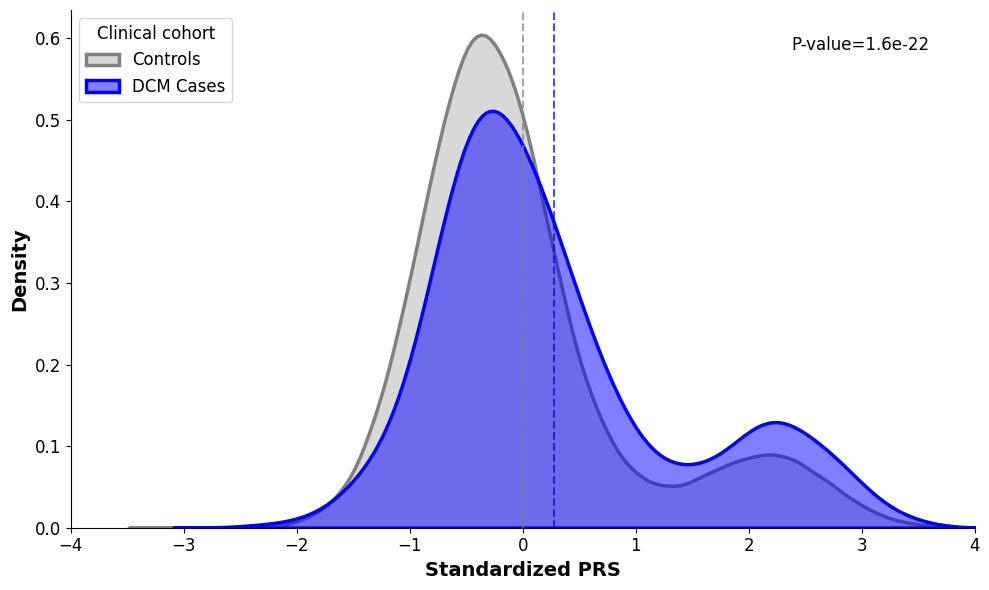

In [25]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Check if we need to flip the direction
dcm_mean_check = dcm_prs_scores['PRS_standardized'].mean()

if dcm_mean_check < 0:
    print(" Flipping PRS direction (cases should have higher PRS)")
    control_prs_scores['PRS_standardized'] = -control_prs_scores['PRS_standardized']
    dcm_prs_scores['PRS_standardized'] = -dcm_prs_scores['PRS_standardized']
    control_prs_scores['PRS'] = -control_prs_scores['PRS']
    dcm_prs_scores['PRS'] = -dcm_prs_scores['PRS']

# Recalculate statistics
dcm_mean_std = dcm_prs_scores['PRS_standardized'].mean()
dcm_std_std = dcm_prs_scores['PRS_standardized'].std()
control_mean = control_prs_scores['PRS'].mean()
control_std = control_prs_scores['PRS'].std()

print("PRS COMPARISON:")
print(f"Controls (n={len(control_prs_scores)}):")
print(f"  Mean: {control_mean:.4f} (SD: {control_std:.4f})")
print(f"  Standardized Mean: 0.0000 (SD: 1.0000)")

print(f"\nDCM cohort (n={len(dcm_prs_scores)}):")
print(f"  Mean: {dcm_prs_scores['PRS'].mean():.4f} (SD: {dcm_prs_scores['PRS'].std():.4f})")
print(f"  Standardized Mean: {dcm_mean_std:.4f} (SD: {dcm_std_std:.4f})")

print(f"\nEffect size (Cohen's d): {dcm_mean_std:.4f}")

# T-test
t_stat, p_value = stats.ttest_ind(dcm_prs_scores['PRS'], control_prs_scores['PRS'])
print(f"\nT-test:")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value: {p_value:.2e}")

# Percentile distribution
print(f"\nDCM patients in control percentiles:")
for pct in [50, 75, 90, 95, 99]:
    threshold = np.percentile(control_prs_scores['PRS'], pct)
    n_above = (dcm_prs_scores['PRS'] > threshold).sum()
    pct_above = (n_above / len(dcm_prs_scores)) * 100
    print(f"  >{pct}th percentile: {n_above} ({pct_above:.1f}%)")

# Create smooth density plot with FIXED Y-AXIS
fig, ax = plt.subplots(figsize=(10, 6))

# Plot smooth density curves
sns.kdeplot(data=control_prs_scores['PRS_standardized'], ax=ax, 
            color='gray', linewidth=2.5, label='Controls', fill=True, alpha=0.3)
sns.kdeplot(data=dcm_prs_scores['PRS_standardized'], ax=ax, 
            color='blue', linewidth=2.5, label='DCM Cases', fill=True, alpha=0.5)

ax.axvline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axvline(dcm_mean_std, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xlabel('Standardized PRS', fontsize=14, fontweight='bold')
ax.set_ylabel('Density', fontsize=14, fontweight='bold')
ax.set_xlim(-4, 4)

# AUTO-ADJUST Y-AXIS to fit all data
y_max = max(ax.get_ylim()[1], 0.6)  # At least 0.6, or higher if needed
ax.set_ylim(0, y_max)

ax.tick_params(labelsize=12)
ax.legend(title='Clinical cohort', fontsize=12, title_fontsize=12, 
          loc='upper left', frameon=True)
ax.text(0.95, 0.95, f'P-value={p_value:.1e}', 
        transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', horizontalalignment='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dcm_prs_distribution_smooth.png", dpi=300, bbox_inches='tight')
print(f"\n Saved: {OUTPUT_DIR}/dcm_prs_distribution_smooth.png")
plt.show()


In [1]:
CHROM_BASE_PATH = "/home/jupyter/gcs"
PRS_VARIANTS_FILE = "/home/jupyter/PGS004946.txt"
PATIENT_ID_FILE = "/home/jupyter/dcm_person_ids.csv" 
RAW_PRS_SCORES = "/home/jupyter/prs_output_dcm/prs_scores_dcm_cohort.tsv"
STANDARD_PRS_SCORES = "/home/jupyter/prs_output_dcm/prs_scores_dcm_standardized.tsv"
PROJECT_ID = "nb-tre-dev-2-483522"
OMOP_DATASET_ID = "nb-tre-dev-2-483522.omop_dataset_v2026_1_1"

In [ ]:
import pandas as pd
import subprocess
import os
OUTPUT_DIR = "/home/jupyter/ancestry_DCM"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("EXTRACT ANCESTRY-INFORMATIVE SNPS")
# Check which chromosomes exist
# Limited list - only need 50K-100K SNPs for ancestry
candidate_chroms = [1, 2, 6, 22]  # Sufficient for ancestry PCA
chrom_list = [] 

for chrom in candidate_chroms: 
    pgen_file = f"{CHROM_BASE_PATH}/chrom-{chrom}/postproc-pgen/dragen.pgen"
    if os.path.exists(pgen_file):
        chrom_list.append(chrom) 
        print(f"   Found chromosome {chrom}")
    else:
        print(f"   Missing chromosome {chrom}")

print(f"\n Found {len(chrom_list)} chromosomes: {chrom_list}")

In [ ]:
import pandas as pd
import subprocess
import os
OUTPUT_DIR = "/home/jupyter/ancestry_DCM"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("EXTRACT ANCESTRY-INFORMATIVE SNPS")

# Limited list - only need 50K-100K SNPs for ancestry
candidate_chroms = [1, 2, 6, 22] 
chrom_list = []  # Start with empty list

for chrom in candidate_chroms: 
    pgen_file = f"{CHROM_BASE_PATH}/chrom-{chrom}/postproc-pgen/dragen.pgen"
    if os.path.exists(pgen_file):
        chrom_list.append(chrom)  
        print(f"   Found chromosome {chrom}")
    else:
        print(f"   Missing chromosome {chrom}")

print(f"\n Found {len(chrom_list)} chromosomes: {chrom_list}")

In [12]:
import pandas as pd
import subprocess
import os
OUTPUT_DIR = "/home/jupyter/ancestry_DCM"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("EXTRACT ANCESTRY-INFORMATIVE SNPS")
# Limited list - only need 50K-100K SNPs for ancestry
candidate_chroms = [1, 2, 6, 22]  # Sufficient for ancestry PCA
chrom_list = []  # Start with empty list

for chrom in candidate_chroms: 
    pgen_file = f"{CHROM_BASE_PATH}/chrom-{chrom}/postproc-pgen/dragen.pgen"
    if os.path.exists(pgen_file):
        chrom_list.append(chrom) 
        print(f"   Found chromosome {chrom}")
    else:
        print(f"   Missing chromosome {chrom}")

print(f"\n Found {len(chrom_list)} chromosomes: {chrom_list}")

EXTRACT ANCESTRY-INFORMATIVE SNPS
   Found chromosome 1
   Found chromosome 2
   Found chromosome 6
   Found chromosome 22

 Found 4 chromosomes: [1, 2, 6, 22]


In [ ]:
print("LD PRUNING FOR ANCESTRY INFERENCE")
# ==========================================
# Parameters for LD pruning:
# - MAF > 0.05 (common variants)
# - Genotyping rate > 95%
# - HWE p > 1e-6
# - LD r² < 0.2
# ==========================================
OUTPUT_DIR = "/home/jupyter/ancestry_DCM"
prune_in_files = []

for chrom in chrom_list:
    print(f"\Processing chromosome {chrom}...")
    pfile_prefix = f"{CHROM_BASE_PATH}/chrom-{chrom}/postproc-pgen/dragen"
    out_prefix = f"{OUTPUT_DIR}/chrom{chrom}_pruned"
    
    # Check files exist
    if not os.path.exists(f"{pfile_prefix}.pgen"):
        print(f"   Skipping - files not found")
        continue
    
    # Quality control + LD pruning
    qc_cmd = [
        PLINK2_PATH,
        "--pfile", pfile_prefix,
        "--threads", "4",
        "--maf", "0.05",           # Remove rare variants
        "--geno", "0.05",          # Remove SNPs with >5% missing
        "--hwe", "1e-6",           # Remove SNPs out of HWE
        "--indep-pairwise", "200", "50", "0.5",  # LD pruning
        "--out", out_prefix
    ]
    
    print(f"  Running: {' '.join(qc_cmd)}")
    result = subprocess.run(qc_cmd, capture_output=True, text=True)
    
    if result.returncode != 0:
        print(f"   Error on chromosome {chrom}:")
        print(result.stderr)
        continue
    
    prune_in_file = f"{out_prefix}.prune.in"
    if os.path.exists(prune_in_file):
        prune_in_files.append(prune_in_file)
        
        # Count SNPs
        with open(prune_in_file) as f:
            snp_count = sum(1 for _ in f)
        print(f"   Kept {snp_count:,} LD-pruned SNPs")
    else:
        print(f"   No output file created")

print(f"\n Completed LD pruning for {len(prune_in_files)} chromosomes")

# Combine all prune.in files
combined_prune_in = f"{OUTPUT_DIR}/ancestry_snps_combined.prune.in"

if len(prune_in_files) == 0:
    print("\n ERROR: No SNPs passed QC")
else:
    with open(combined_prune_in, 'w') as outf:
        for prune_file in prune_in_files:
            with open(prune_file) as inf:
                outf.write(inf.read())
    
    with open(combined_prune_in) as f:
        total_snps = sum(1 for _ in f)
    
    print(f"\n Total ancestry-informative SNPs: {total_snps:,}")
    print(f" Saved to: {combined_prune_in}")

LD PRUNING FOR ANCESTRY INFERENCE
\ Processing chromosome 1...
  Running: /opt/conda/envs/mf_cm/bin/plink2 --pfile /home/jupyter/gcs/chrom-1/postproc-pgen/dragen --threads 4 --maf 0.05 --geno 0.05 --hwe 1e-6 --indep-pairwise 200 50 0.5 --out /home/jupyter/ancestry_DCM/chrom1_pruned
